# Perturbation Generator & Adversarial Attacks
## Adversarial Robustness Testing & Trust Safety Pipeline

## Imports

In [1]:
import os
import cv2
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFilter
from copy import deepcopy

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"OpenCV  : {cv2.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Albumentations: {A.__version__}")
print("All imports successful.")


Device  : cpu
OpenCV  : 5.0.0
NumPy   : 1.24.3
Albumentations: 2.0.8
All imports successful.


## Configuration

In [2]:
# Paths
PROJECT_DIR      = Path(r"C:/adversarial_doc_project")
DATA_DIR         = PROJECT_DIR / "data"
FRAMES_DIR       = DATA_DIR / "frames"
SPLITS_DIR       = DATA_DIR / "splits"
AUGMENTED_DIR    = DATA_DIR / "augmented"
OUTPUTS_DIR      = PROJECT_DIR / "outputs"
CHECKPOINTS_DIR  = PROJECT_DIR / "checkpoints"

# Augmented class directories
REAL_DIR      = AUGMENTED_DIR / "real"
BENIGN_DIR    = AUGMENTED_DIR / "benign"
MALICIOUS_DIR = AUGMENTED_DIR / "malicious"

for d in [AUGMENTED_DIR, REAL_DIR, BENIGN_DIR, MALICIOUS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Configuration
IMG_SIZE         = 224
CLASS_NAMES      = {0: "real", 1: "benign", 2: "malicious"}
CLASS_LIST       = ["real", "benign", "malicious"]

# Number of benign and malicious samples to generate
# We match the real class size for balance
N_BENIGN_PER_FRAME    = 1   # 1 benign variant per real frame
N_MALICIOUS_PER_FRAME = 1   # 1 malicious variant per real frame

# Baseline model path
BASELINE_MODEL_PATH = CHECKPOINTS_DIR / "baseline_efficientnet_best.pth"

# Verify everything exists
assert (SPLITS_DIR / "train.csv").exists(), "train.csv not found. Run Week 1."
assert BASELINE_MODEL_PATH.exists(), "Baseline model not found. Run Week 2."

print("Configuration ready.")
print(f"Project dir   : {PROJECT_DIR}")
print(f"Augmented dir : {AUGMENTED_DIR}")
print(f"Baseline model: {BASELINE_MODEL_PATH}")


Configuration ready.
Project dir   : C:\adversarial_doc_project
Augmented dir : C:\adversarial_doc_project\data\augmented
Baseline model: C:\adversarial_doc_project\checkpoints\baseline_efficientnet_best.pth


## Load Frame Index

In [12]:
# Load splits
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df   = pd.read_csv(SPLITS_DIR / "val.csv")
test_df  = pd.read_csv(SPLITS_DIR / "test.csv")
full_df  = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Total frames  : {len(full_df)}")
print(f"Train frames  : {len(train_df)}")
print(f"Val frames    : {len(val_df)}")
print(f"Test frames   : {len(test_df)}")

# Verify frame paths exist
sample_path = full_df["frame_path"].iloc[0]
assert Path(sample_path).exists(), f"Frame not found: {sample_path}"
print(f"\nSample frame path: {sample_path}")
print("Frame paths verified.")


Train : 14700 frames
Val   : 3150 frames
Test  : 3150 frames

Class distribution in train:
label_name
real         4900
benign       4900
malicious    4900

Sample path verified: C:\adversarial_doc_project\data\augmented\real\midv2019_videos_DG01_mp4_frame00000_real.jpg


## Benign Perturbation Pipeline

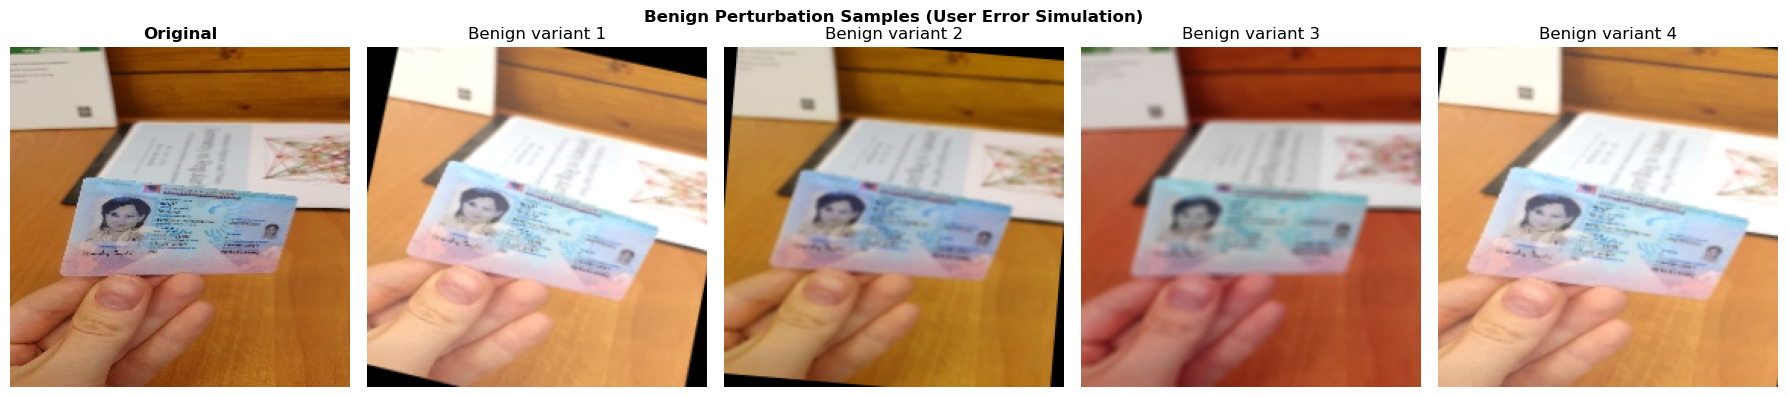

Benign samples saved: C:\adversarial_doc_project\outputs\week3_benign_samples.png


In [13]:
# Benign augmentation pipeline
# Low-intensity transforms that mimic real user capture conditions

benign_transform = A.Compose([
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=(-0.3, 0.3),
            contrast_limit=(-0.2, 0.2),
            p=1.0),
        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=1.0),
    ], p=0.7),
    A.OneOf([
        A.Blur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=(3, 5), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.6),
    A.Rotate(limit=(-12, 12), p=0.6),
    A.GaussNoise(std_range=(0.01, 0.03), p=0.4),
    A.Perspective(scale=(0.01, 0.04), p=0.3),
])


def apply_benign(image_path, output_path):
    """
    Apply benign perturbation to an image.
    Saves result to output_path.
    Returns True if successful.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return False
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    augmented = benign_transform(image=img_rgb)["image"]
    result = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(output_path), result)
    return True


# Test benign pipeline
test_img_path = Path(full_df["frame_path"].iloc[0])
test_out_path = OUTPUTS_DIR / "test_benign_sample.jpg"
apply_benign(test_img_path, test_out_path)

# Visualise
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Benign Perturbation Samples (User Error Simulation)", fontsize=12, fontweight="bold")

orig = cv2.cvtColor(cv2.imread(str(test_img_path)), cv2.COLOR_BGR2RGB)
axes[0].imshow(orig)
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

for i in range(1, 5):
    img_rgb = cv2.cvtColor(cv2.imread(str(test_img_path)), cv2.COLOR_BGR2RGB)
    aug = benign_transform(image=img_rgb)["image"]
    axes[i].imshow(aug)
    axes[i].set_title(f"Benign variant {i}")
    axes[i].axis("off")

plt.tight_layout()
out = OUTPUTS_DIR / "week3_benign_samples.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Benign samples saved: {out}")


## Malicious Perturbation Pipeline

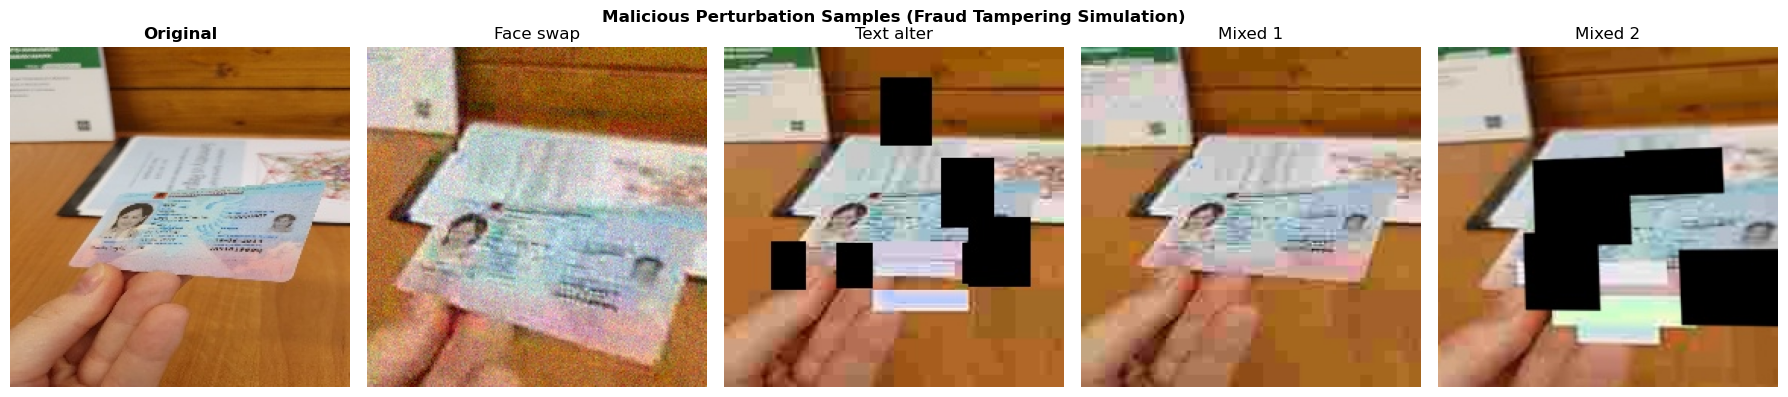

Malicious samples saved: C:\adversarial_doc_project\outputs\week3_malicious_samples.png


In [14]:
def apply_face_region_swap(img_rgb):
    """
    Simulate face swap by copy-pasting and distorting
    the upper-left region of the document onto itself
    with colour and brightness shift — mimics a pasted face.
    """
    h, w = img_rgb.shape[:2]
    img = img_rgb.copy()

    # Define face region (top-left quadrant — where face typically is on ID)
    face_h, face_w = h // 3, w // 3
    face_region = img[0:face_h, 0:face_w].copy()

    # Distort the copied region
    face_region = cv2.resize(face_region, (face_w + 10, face_h + 10))
    face_region = face_region[5:face_h+5, 5:face_w+5]

    # Apply colour shift to make it look pasted
    face_region = np.clip(face_region.astype(np.int32) + 
                          np.random.randint(-30, 30, face_region.shape), 
                          0, 255).astype(np.uint8)

    # Paste back — creates visible boundary artefact
    img[0:face_h, 0:face_w] = face_region
    return img


def apply_text_alteration(img_rgb):
    """
    Simulate text field alteration by drawing rectangles
    over text areas and adding noise — mimics number/date editing.
    """
    img = Image.fromarray(img_rgb)
    draw = ImageDraw.Draw(img)
    h, w = img_rgb.shape[:2]

    # Draw 2-3 filled rectangles over text field areas
    n_alterations = random.randint(2, 3)
    for _ in range(n_alterations):
        x1 = random.randint(w // 4, w // 2)
        y1 = random.randint(h // 2, int(h * 0.8))
        x2 = x1 + random.randint(30, 80)
        y2 = y1 + random.randint(8, 16)
        color = tuple(np.random.randint(200, 255, 3).tolist())
        draw.rectangle([x1, y1, x2, y2], fill=color)

    return np.array(img)


# Malicious augmentation pipeline 
malicious_transform = A.Compose([
    A.ImageCompression(quality_range=(5, 25), p=0.8),
    A.CoarseDropout(
        num_holes_range=(3, 6),
        hole_height_range=(20, 50),
        hole_width_range=(20, 50),
        p=0.7),
    A.Perspective(scale=(0.08, 0.15), p=0.5),
    A.GaussNoise(std_range=(0.05, 0.1), p=0.5),
])


def apply_malicious(image_path, output_path, tampering_type="mixed"):
    """
    Apply malicious tampering to an image.
    tampering_type: 'face_swap', 'text_alter', or 'mixed'
    Saves result to output_path. Returns True if successful.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return False
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply structural tampering
    r = random.random()
    if tampering_type == "face_swap" or (tampering_type == "mixed" and r < 0.4):
        img_rgb = apply_face_region_swap(img_rgb)
    elif tampering_type == "text_alter" or (tampering_type == "mixed" and r < 0.8):
        img_rgb = apply_text_alteration(img_rgb)
    else:
        img_rgb = apply_face_region_swap(img_rgb)
        img_rgb = apply_text_alteration(img_rgb)

    # Apply additional compression/noise artefacts
    augmented = malicious_transform(image=img_rgb)["image"]
    result = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(output_path), result)
    return True


# Test malicious pipeline 
test_img_path = Path(full_df["frame_path"].iloc[5])

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Malicious Perturbation Samples (Fraud Tampering Simulation)", 
             fontsize=12, fontweight="bold")

orig = cv2.cvtColor(cv2.imread(str(test_img_path)), cv2.COLOR_BGR2RGB)
axes[0].imshow(orig)
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

tampering_types = ["face_swap", "text_alter", "mixed", "mixed"]
labels = ["Face swap", "Text alter", "Mixed 1", "Mixed 2"]
for i, (ttype, label) in enumerate(zip(tampering_types, labels), 1):
    tmp_path = OUTPUTS_DIR / f"tmp_mal_{i}.jpg"
    apply_malicious(test_img_path, tmp_path, tampering_type=ttype)
    mal_img = cv2.cvtColor(cv2.imread(str(tmp_path)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(mal_img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
out = OUTPUTS_DIR / "week3_malicious_samples.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Malicious samples saved: {out}")


## Generate Full Augmented Dataset

In [6]:
print("Generating augmented dataset...")
print(f"Real frames    : {len(full_df)}")
print(f"Benign target  : {len(full_df) * N_BENIGN_PER_FRAME}")
print(f"Malicious target: {len(full_df) * N_MALICIOUS_PER_FRAME}")
print("-" * 60)

augmented_records = []
failed = 0

for idx, row in tqdm(full_df.iterrows(), total=len(full_df), desc="Augmenting"):
    src_path  = Path(row["frame_path"])
    split     = row["split"]
    clip_name = row["clip_name"]
    base_name = f"{clip_name}_frame{idx:05d}"

    if not src_path.exists():
        failed += 1
        continue

    # Class 0: Real - copy original
    real_out = REAL_DIR / f"{base_name}_real.jpg"
    if not real_out.exists():
        shutil.copy2(src_path, real_out)
    augmented_records.append({
        "frame_path" : str(real_out),
        "label"      : 0,
        "label_name" : "real",
        "split"      : split,
        "clip_name"  : clip_name,
        "source"     : str(src_path),
    })

    # Class 1: Benign — apply benign transform 
    for b in range(N_BENIGN_PER_FRAME):
        benign_out = BENIGN_DIR / f"{base_name}_benign_{b}.jpg"
        if not benign_out.exists():
            apply_benign(src_path, benign_out)
        augmented_records.append({
            "frame_path" : str(benign_out),
            "label"      : 1,
            "label_name" : "benign",
            "split"      : split,
            "clip_name"  : clip_name,
            "source"     : str(src_path),
        })

    # Class 2: Malicious — apply malicious tampering
    for m in range(N_MALICIOUS_PER_FRAME):
        malicious_out = MALICIOUS_DIR / f"{base_name}_malicious_{m}.jpg"
        if not malicious_out.exists():
            apply_malicious(src_path, malicious_out, tampering_type="mixed")
        augmented_records.append({
            "frame_path" : str(malicious_out),
            "label"      : 2,
            "label_name" : "malicious",
            "split"      : split,
            "clip_name"  : clip_name,
            "source"     : str(src_path),
        })

# Save augmented index
aug_df = pd.DataFrame(augmented_records)
aug_index_path = DATA_DIR / "augmented_frame_index.csv"
aug_df.to_csv(aug_index_path, index=False)

print("-" * 60)
print(f"Augmentation complete.")
print(f"Total augmented frames: {len(aug_df)}")
print(f"Failed frames         : {failed}")
print(f"\nClass distribution:")
print(aug_df["label_name"].value_counts().to_string())
print(f"\nAugmented index saved: {aug_index_path}")


Generating augmented dataset...
Real frames    : 7000
Benign target  : 7000
Malicious target: 7000
------------------------------------------------------------


Augmenting: 100%|██████████████████████████████████████████████████████████████████| 7000/7000 [01:38<00:00, 70.94it/s]


------------------------------------------------------------
Augmentation complete.
Total augmented frames: 21000
Failed frames         : 0

Class distribution:
label_name
real         7000
benign       7000
malicious    7000

Augmented index saved: C:\adversarial_doc_project\data\augmented_frame_index.csv


## Save Augmented Train/Val/Test Splits

In [7]:
# Split augmented data
aug_train = aug_df[aug_df["split"] == "train"]
aug_val   = aug_df[aug_df["split"] == "val"]
aug_test  = aug_df[aug_df["split"] == "test"]

aug_train.to_csv(SPLITS_DIR / "aug_train.csv", index=False)
aug_val.to_csv(SPLITS_DIR / "aug_val.csv",     index=False)
aug_test.to_csv(SPLITS_DIR / "aug_test.csv",   index=False)

print("Augmented splits saved:")
print(f"  aug_train.csv : {len(aug_train)} frames")
print(f"  aug_val.csv   : {len(aug_val)} frames")
print(f"  aug_test.csv  : {len(aug_test)} frames")
print()
print("Class balance per split:")
for split_name, split_data in [("train", aug_train), ("val", aug_val), ("test", aug_test)]:
    counts = split_data["label_name"].value_counts()
    print(f"  {split_name}: real={counts.get('real',0)}, "
          f"benign={counts.get('benign',0)}, "
          f"malicious={counts.get('malicious',0)}")


Augmented splits saved:
  aug_train.csv : 14700 frames
  aug_val.csv   : 3150 frames
  aug_test.csv  : 3150 frames

Class balance per split:
  train: real=4900, benign=4900, malicious=4900
  val: real=1050, benign=1050, malicious=1050
  test: real=1050, benign=1050, malicious=1050


## Visualise Augmented Dataset Distribution

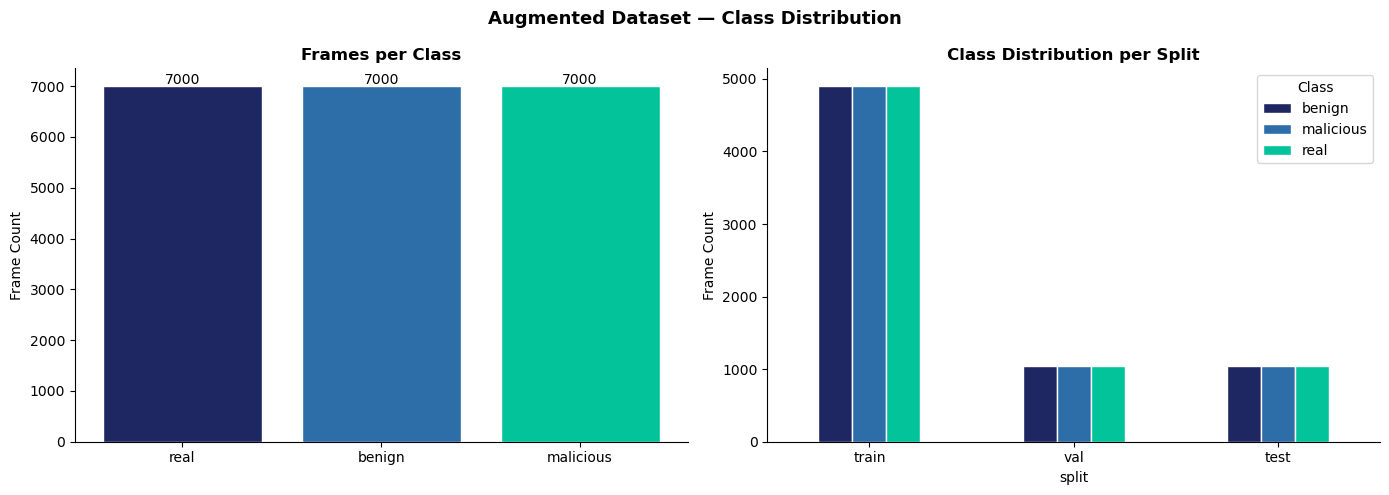

Distribution plot saved: C:\adversarial_doc_project\outputs\week3_class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Augmented Dataset — Class Distribution", fontsize=13, fontweight="bold")

# Overall class distribution
ax = axes[0]
class_counts = aug_df["label_name"].value_counts()
colors = ["#1E2761", "#2D6EA8", "#02C39A"]
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor="white")
ax.set_title("Frames per Class", fontweight="bold")
ax.set_ylabel("Frame Count")
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
            str(v), ha="center", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# Per split class distribution
ax = axes[1]
split_class = aug_df.groupby(["split", "label_name"]).size().unstack(fill_value=0)
split_class = split_class.reindex(["train", "val", "test"])
split_class.plot(kind="bar", ax=ax, color=colors, edgecolor="white", rot=0)
ax.set_title("Class Distribution per Split", fontweight="bold")
ax.set_ylabel("Frame Count")
ax.legend(title="Class")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = OUTPUTS_DIR / "week3_class_distribution.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Distribution plot saved: {out}")


## Test Baseline Model on Augmented Data

In [9]:
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score

class AugmentedDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        img   = Image.open(row["frame_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load baseline model
def build_efficientnet(num_classes=3):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

baseline_model = build_efficientnet(num_classes=3)
checkpoint = torch.load(BASELINE_MODEL_PATH, map_location=DEVICE, weights_only=True)
baseline_model.load_state_dict(checkpoint["model_state"])
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()
print(f"Baseline model loaded from epoch {checkpoint['epoch']}")

# Evaluate on augmented validation set (sample of 300 for speed)
aug_val_sample = aug_val.sample(min(300, len(aug_val)), random_state=SEED)
val_dataset    = AugmentedDataset(aug_val_sample, transform=val_transform)
val_loader     = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating baseline on augmented data"):
        imgs   = imgs.to(DEVICE)
        outputs = baseline_model(imgs)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

baseline_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print()
print("=" * 55)
print("BASELINE MODEL — PRE-HARDENING BENCHMARK")
print("(on augmented 3-class validation data)")
print("=" * 55)
print(f"  Weighted F1: {baseline_f1:.4f}")
print()
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1, 2],
    target_names=CLASS_LIST,
    zero_division=0
))
print("=" * 55)
print("This is the score we aim to improve in Week 4.")


Baseline model loaded from epoch 1


Evaluating baseline on augmented data: 100%|███████████████████████████████████████████| 19/19 [00:12<00:00,  1.52it/s]


BASELINE MODEL — PRE-HARDENING BENCHMARK
(on augmented 3-class validation data)
  Weighted F1: 0.1826

              precision    recall  f1-score   support

        real       0.35      1.00      0.52       102
      benign       0.00      0.00      0.00       106
   malicious       1.00      0.01      0.02        92

    accuracy                           0.34       300
   macro avg       0.45      0.34      0.18       300
weighted avg       0.43      0.34      0.18       300

This is the score we aim to improve in Week 4.


## Systematic Threshold Analysis

In [10]:
def get_model_confidence(model, image_path, transform, device):
    """
    Get the model's confidence score for class 0 (real) on a single image.
    Returns confidence value between 0 and 1.
    """
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
    return probs[0][0].item()  # Confidence for class 0 (real)


single_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Use 10 sample images for threshold analysis
sample_paths = full_df["frame_path"].sample(10, random_state=SEED).tolist()

# Threshold sweep parameters
sweep_configs = {
    "Blur Radius": {
        "values": list(range(1, 16, 2)),  # 1, 3, 5, 7, 9, 11, 13, 15
        "label" : "Blur kernel size"
    },
    "Brightness Shift": {
        "values": [round(v, 1) for v in np.arange(0.0, 1.1, 0.1)],
        "label" : "Brightness limit"
    },
    "Rotation Angle": {
        "values": list(range(0, 46, 5)),  # 0, 5, 10, 15... 45
        "label" : "Rotation degrees"
    },
    "Compression Quality": {
        "values": list(range(10, 101, 10)),  # 10, 20... 100
        "label" : "JPEG quality"
    },
}

threshold_results = {}

print("Running threshold sweep analysis...")
print("This tests model confidence at each perturbation intensity level.")
print("-" * 60)

for perturbation_name, config in sweep_configs.items():
    print(f"  Sweeping: {perturbation_name}")
    confidences_per_level = []

    for intensity in config["values"]:
        level_confidences = []

        for img_path in sample_paths:
            img = cv2.imread(img_path)
            if img is None:
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Apply perturbation at this intensity
            if perturbation_name == "Blur Radius":
                k = intensity if intensity % 2 == 1 else intensity + 1
                perturbed = cv2.GaussianBlur(img_rgb, (k, k), 0)

            elif perturbation_name == "Brightness Shift":
                hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
                hsv[:,:,2] = np.clip(hsv[:,:,2] * (1 + intensity), 0, 255)
                perturbed = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

            elif perturbation_name == "Rotation Angle":
                h, w = img_rgb.shape[:2]
                M = cv2.getRotationMatrix2D((w//2, h//2), intensity, 1.0)
                perturbed = cv2.warpAffine(img_rgb, M, (w, h))

            elif perturbation_name == "Compression Quality":
                encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), intensity]
                _, encoded = cv2.imencode(".jpg", img_rgb, encode_param)
                perturbed = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
                perturbed = cv2.cvtColor(perturbed, cv2.COLOR_BGR2RGB)

            # Save temp and get confidence
            tmp_path = OUTPUTS_DIR / "_tmp_threshold.jpg"
            cv2.imwrite(str(tmp_path), cv2.cvtColor(perturbed, cv2.COLOR_RGB2BGR))

            conf = get_model_confidence(
                baseline_model, tmp_path, single_transform, DEVICE)
            level_confidences.append(conf)

        confidences_per_level.append(np.mean(level_confidences))

    threshold_results[perturbation_name] = {
        "values"       : config["values"],
        "confidences"  : confidences_per_level,
        "label"        : config["label"],
    }

# Clean up temp file
if (OUTPUTS_DIR / "_tmp_threshold.jpg").exists():
    (OUTPUTS_DIR / "_tmp_threshold.jpg").unlink()

print("-" * 60)
print("Threshold sweep complete.")


Running threshold sweep analysis...
This tests model confidence at each perturbation intensity level.
------------------------------------------------------------
  Sweeping: Blur Radius
  Sweeping: Brightness Shift
  Sweeping: Rotation Angle
  Sweeping: Compression Quality
------------------------------------------------------------
Threshold sweep complete.


## Plot Threshold Analysis Results

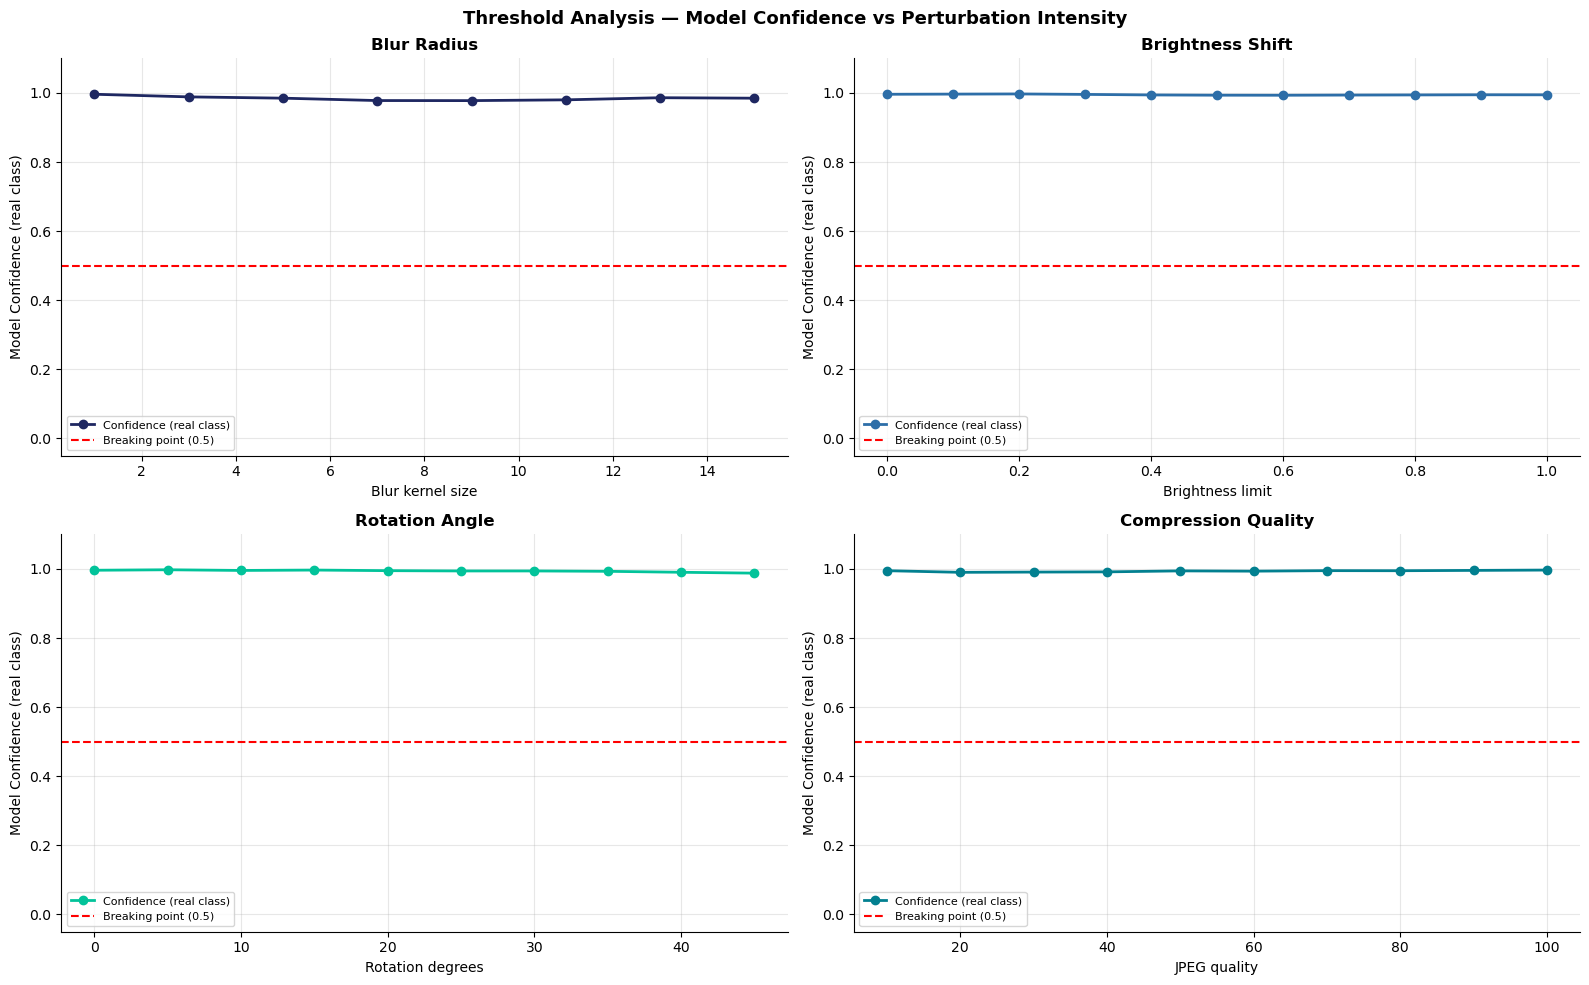

Threshold analysis plot saved: C:\adversarial_doc_project\outputs\week3_threshold_analysis.png

BREAKING POINT SUMMARY:
---------------------------------------------
  Blur Radius              : breaks at Never
  Brightness Shift         : breaks at Never
  Rotation Angle           : breaks at Never
  Compression Quality      : breaks at Never


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Threshold Analysis — Model Confidence vs Perturbation Intensity",
             fontsize=13, fontweight="bold")

axes_flat = axes.flatten()
colors    = ["#1E2761", "#2D6EA8", "#02C39A", "#028090"]

for i, (name, data) in enumerate(threshold_results.items()):
    ax = axes_flat[i]
    values      = data["values"]
    confidences = data["confidences"]

    ax.plot(values, confidences, color=colors[i], marker="o",
            linewidth=2, markersize=6, label="Confidence (real class)")
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1.5,
               label="Breaking point (0.5)")

    # Find breaking point
    breaking_idx = next((j for j, c in enumerate(confidences) if c < 0.5), None)
    if breaking_idx is not None:
        bx = values[breaking_idx]
        by = confidences[breaking_idx]
        ax.annotate(f"Breaks at {bx}",
                    xy=(bx, by), xytext=(bx, by + 0.15),
                    arrowprops=dict(arrowstyle="->", color="red"),
                    color="red", fontsize=9, fontweight="bold")

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel(data["label"])
    ax.set_ylabel("Model Confidence (real class)")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = OUTPUTS_DIR / "week3_threshold_analysis.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Threshold analysis plot saved: {out}")

# Print summary
print()
print("BREAKING POINT SUMMARY:")
print("-" * 45)
for name, data in threshold_results.items():
    values      = data["values"]
    confidences = data["confidences"]
    breaking    = next((values[j] for j, c in enumerate(confidences) if c < 0.5), "Never")
    print(f"  {name:<25}: breaks at {breaking}")
